<a href="https://colab.research.google.com/github/Jorge-Ruiz-Troccoli/Data-Science-II/blob/main/Clase%20015/regresiones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###  Selección del Algoritmo y Entrenamiento del Modelo II
## Coderhouse - Data Science

Profe Jorge Ruiz

REGRESIÓN LINEAL SIMPLE

In [ ]:
#Importacion ded librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

%matplotlib inline

In [ ]:
#Importacion de los datos
dataset = pd.read_csv("https://raw.githubusercontent.com/Jorge-Ruiz-Troccoli/Data-Science-II/refs/heads/main/Clase%20015/student_scores.csv", sep = ",")

In [ ]:
#Vemos el dataset
dataset.head()

In [ ]:
#Shape
dataset.shape

In [ ]:
# estadísticos básicos
dataset.describe()

In [ ]:
#Ploteamos el dataset
dataset.plot(x='Hours', y='Scores', style="o")
plt.title('Hours vs Percentage')
plt.xlabel('Hours Studied')
plt.ylabel('Percentage Score')
plt.show()

In [ ]:
dataset.corr()

In [ ]:
dataset.corr("spearman")

In [ ]:
#Preparacion de datos
X=dataset["Hours"]
y=dataset["Scores"]

In [ ]:
# Convertir el objeto Series en un arreglo NumPy
X = np.array(X)
X.ndim

In [ ]:
#Empezamos a crear nuestro modelo
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.reshape(-1, 1).ndim

In [ ]:
#Entrenando el modelo
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train.reshape(-1, 1), y_train)

In [ ]:
#Recuperamos la intersección
print(regressor.intercept_)

In [ ]:
#La pendiente
print(regressor.coef_)

La formula de la recta es: y= 9,68x+2,83

In [ ]:
#Hacemos nuestras predicciones
y_pred = regressor.predict(X_test.reshape(-1,1))
y_pred

In [ ]:
X_test

El y_pred es una matriz numpy que contiene todos los valores predichos para los valores de entrada en la X_test

In [ ]:
#Convertimos en df la salida
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.round(1)})
df

**Evaluación del modelo**:

El último paso es evaluar el rendimiento del algoritmo. Este paso es particularmente importante para comparar qué tan bien funcionan los diferentes algoritmos en un conjunto de datos en particular. Para los algoritmos de regresión, se utilizan comúnmente tres métricas de evaluación:

* El error absoluto medio (MAE)
* El error cuadrático medio (MSE)
* Root Mean Squared Error (RMSE)

In [ ]:
import numpy as np
def mse(actual, predicted):
    return np.mean(np.square(actual-predicted))

In [ ]:
def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

In [ ]:
mape(y_test, y_pred)

In [ ]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred)) # MAE
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred)) # MSE
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred))) # RMSE

In [ ]:
from sklearn.metrics import r2_score
print('El r^2 es:',r2_score(y_test,y_pred))

In [ ]:
X_test.shape

In [ ]:
# Calcular el R^2 ajustado
n = X_test.shape[0]  # número de observaciones
p = 1   # número de predictores (excluyendo el intercepto)

r_squared = r2_score(y_test,y_pred)
r_squared_adjusted = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

print("R^2 ajustado:", r_squared_adjusted)

# tener presente que R2 ajustado es siempre menor que o igual a R2

## REGRESIÓN LINEAL MÚLTIPLE

La regresión lineal múltiple es el caso más general y además el más común de la regresión lineal. Como en el caso de la regresión lineal simple, hay aún una variable predictando, (y), pero el número de variables predictoras (x) es mayor que uno.

Sea K el número de variables predictoras, entonces la ecuación correspondiente es:


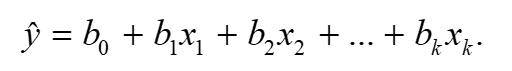

Cada una de las x variables tiene su propio coeficiente análogo a la pendiente. El intercepto se denota por b0. Los coeficientes de la ecuación se denotan comúnmente como parámetros de la regresión y el intercepto se denomina constante de la regresión.


In [ ]:
dataset = pd.read_csv("https://raw.githubusercontent.com/Jorge-Ruiz-Troccoli/Data-Science-II/refs/heads/main/Clase%20015/petrol_consumption.csv", sep = ",")

In [ ]:
#Vemos el head
dataset.head()

In [ ]:
dataset.columns

Petrol_tax: Impuesto a la gasolina/nafta en el área correspondiente.

Average_income: Ingreso promedio en el área correspondiente.

Paved_Highways: Longitud de las carreteras pavimentadas en millas por área.

Population_Driver_licence(%): Porcentaje de la población con licencia de conducir en el área correspondiente.

Petrol_Consumption: Consumo de gasolina en millones de galones en el área correspondiente.

In [ ]:
# estadísticos básicos
dataset.describe()

In [ ]:
dataset.info()

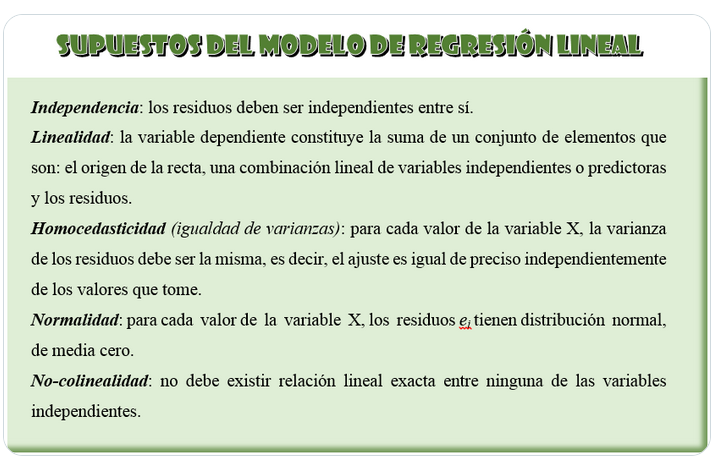

In [ ]:
dataset.corr()

In [ ]:
#Preparación de datos
X = dataset[['Petrol_tax', 'Average_income', 'Population_Driver_licence(%)']]
y = dataset['Petrol_Consumption']

 ## Selección de predictor.

 Casi siempre hay más predictores potenciales que los que uno puede usar en una regresión, y hallar un buen subconjunto de estos. En casos particulares es más difícil de lo que uno pueda imaginarse de inicio.

El proceso no es definitivamente una simple adición  de miembros en una lista de predictores potenciales hasta que se logre una buena relación, ya que hay peligros asociados con la inclusión de demasiados predictores en ecuaciones de pronóstico.


Supongamos que en un conjunto de predictores potenciales para una regresión particular se incluyan todos los predictores físicamente relevantes, con la exclusión de los irrelevantes. Este ideal se cumple raramente.

Aún si esto pudiera ser, no es útil incluir todos los predictores potenciales en una ecuación de regresión final. Esto se debe a que las variables predictoras están casi siempre correlacionadas entre sí, así que el conjunto total de todos los predictores potenciales contiene información redundante.

Como un aspecto práctico, entonces, se necesita un método para seleccionar entre los predictores potenciales y decidir cuantos de ellos son suficientes para producir una buena ecuación de pronóstico.


# Factor de inflación de la varianza (Variance inflation factor)

In [ ]:
# https://es.wikipedia.org/wiki/Factor_de_inflaci%C3%B3n_de_la_varianza
# https://statologos.com/como-calcular-vif-en-python/

# Drop the target variable 'Petrol_Consumption' from the dataset
data_ = dataset.drop(columns=['Petrol_Consumption'])

# Manual VIF Calculation
vif_manual = {}

for feature in data_ .columns:
    # Define the target variable (current feature) and predictors (all other features)
    y1 = data_[feature]
    X1 = data_.drop(columns=[feature])

    # Fit the linear regression model
    model = LinearRegression().fit(X1, y1)

    # Calculate R-squared
    r_squared = model.score(X1, y1)

    # Calculate VIF
    vif = 1 / (1 - r_squared)
    vif_manual[feature] = vif

# Convert the dictionary to a DataFrame for better display
vif_manual_df = pd.DataFrame(list(vif_manual.items()), columns=['Feature', 'VIF'])
print(vif_manual_df)

# adaptado desde https://www.datacamp.com/es/tutorial/variance-inflation-factor

VIF igual a 1: Un VIF de 1 indica que no hay colinealidad entre la variable predictora y las demás variables. Esto significa que la variable no está correlacionada con ninguna otra variable en el modelo.

VIF entre 1 y 5: Un VIF en este rango generalmente se considera aceptable y sugiere una colinealidad leve o moderada entre la variable predictora y otras variables. No es motivo de preocupación grave, pero se debe tener en cuenta al interpretar los coeficientes de regresión.

VIF mayor a 5: Un VIF mayor a 5 indica una colinealidad sustancial entre la variable predictora y al menos una de las otras variables. Esto puede sugerir que la variable está  correlacionada con otras variables y puede dificultar la interpretación de los coeficientes de regresión.

VIF muy alto: En casos donde el VIF es extremadamente alto (por ejemplo, superior a 10 o 20), se considera que la colinealidad es muy fuerte. Esto indica que la variable está altamente correlacionada con otras variables y puede afectar significativamente las estimaciones de los coeficientes de regresión.

In [ ]:
ataset.shape

In [ ]:
df.info()

In [ ]:
y

In [ ]:
X

In [ ]:
#Separacion en train y test
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Crear un objeto StandardScaler
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
#Entrenamiento del modelo
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

In [ ]:
#Realizando las predicciones
y_pred_train = regressor.predict(X_train)
y_pred_test = regressor.predict(X_test)

Como se dijo anteriormente, en caso de regresión lineal multivariable, el modelo de regresión tiene que encontrar los coeficientes más óptimos para todos los atributos. Para ver qué coeficientes ha elegido nuestro modelo de regresión, podemos ejecutar el siguiente script:

In [ ]:
regressor.coef_

In [ ]:
regressor.intercept_

In [ ]:
coeff_df = pd.DataFrame(regressor.coef_, X.columns, columns=['Coefficient'])
coeff_df

Para comparar los valores de salida reales X_test con los valores predichos, convertimos en df:

In [ ]:
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test})
df

In [ ]:
#Evaluación de Modelos
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_test))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_test))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_train,y_pred_train)

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred_test)

In [ ]:
# Calcular el R^2 ajustado
n = X_test.shape[0]  # número de observaciones
p = len(X_test.columns) # número de predictores (excluyendo el intercepto)

r_squared = r2_score(y_test,y_pred_test)
r_squared_adjusted = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

print("R^2 ajustado:", r_squared_adjusted)

# tener presente que R2 ajustado es siempre menor que o igual a R2

Normalidad en los residuos

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

# Obtener los residuales del modelo
residuales = y_train - y_pred_train

# Crear el QQ plot con statsmodels
sm.qqplot(residuales, line='s')
plt.show()

El QQ plot compara los cuantiles de los residuos con los cuantiles esperados de una distribución teórica (generalmente una distribución normal) y ayuda a verificar si los residuos siguen una distribución aproximadamente normal.

In [ ]:
# no parece ser normal  los residuos, probemos con un histrograma
residuales.hist()

# La NO correlación entre los residuos

Un valor de 2 indica que no hay autocorrelación.

Un valor entre 0 y 2 indica autocorrelación positiva (común en datos de series de tiempo).

Un valor entre 2 y 4 indica autocorrelación negativa (menos común en datos de series de tiempo).

In [ ]:

import statsmodels.api as sm

# Realizar el test de Durbin-Watson en los residuos
dw_test= sm.stats.stattools.durbin_watson(residuales)


print("Estadístico DW:", dw_test)

# https://statologos.com/test-de-durbin-watson-en-python/


# comprobar la homocedasticidad

In [ ]:
from statsmodels.stats.diagnostic import het_white


# Agregar una columna de unos a la matriz de características
X_with_constant = sm.add_constant(X_train)

# Realizar la prueba de White
white_test = het_white(residuales, X_with_constant)

# Obtener el valor p de la prueba
p_value = white_test[1]

# Imprimir el valor p de la prueba
print("Valor p de la prueba de White:", p_value)

# https://www.statology.org/white-test-in-python/

# Si el tamaño de la muestra es pequeño, la prueba puede tener menos poder para detectar la heterocedasticidad,
#incluso si hay indicios visuales en el gráfico de dispersión.

(H0): Hay homocedasticidad presente (los residuos están igualmente dispersos).

(HA): Hay heterocedasticidad presente (los residuos no están igualmente dispersos)

In [ ]:
import matplotlib.pyplot as plt

# Graficar los residuos en función de los valores ajustados
plt.scatter(y_pred_train, residuales)
plt.axhline(0, color='red', linestyle='--')  # Línea horizontal en cero
plt.xlabel('Valores estimados')
plt.ylabel('Residuos')
plt.title('Gráfico de dispersión de residuos')
plt.show()

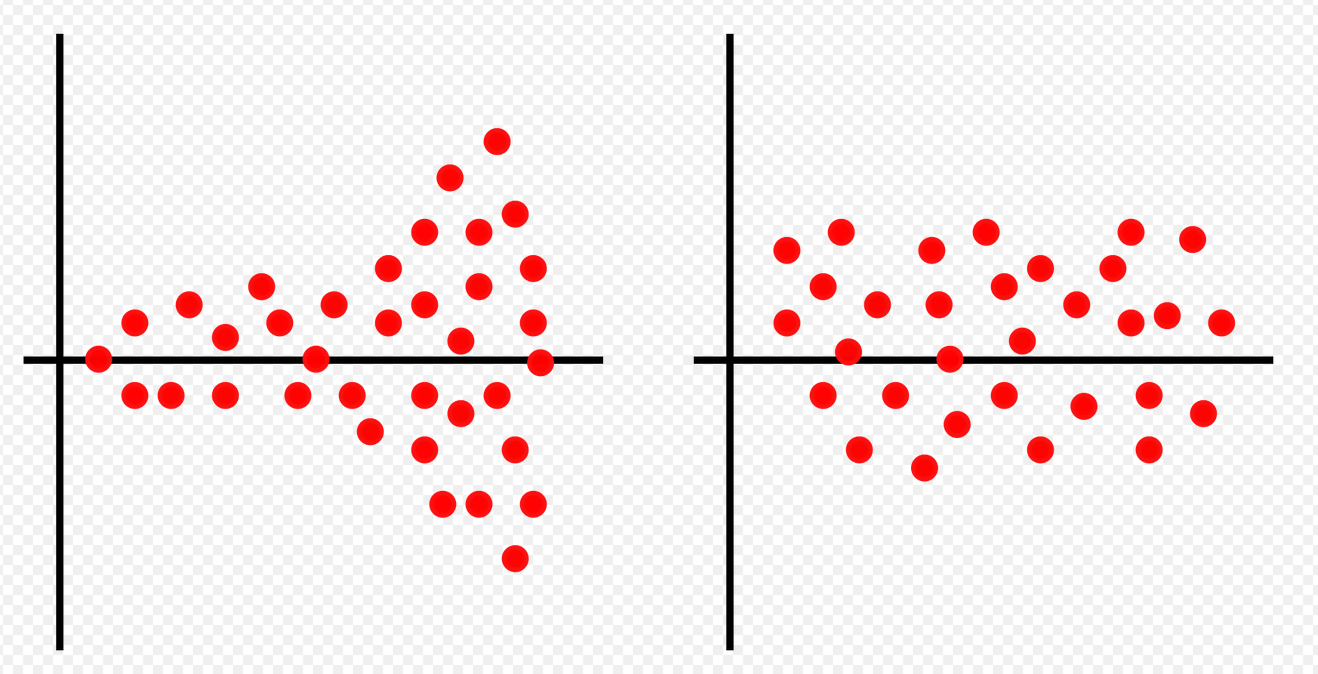

Algunas enseñanzas del ejemplo.

1. Debemos comenzar el desarrollo de una ecuación de regresión por la selección  de variables independientes con una clara justificación teórica sólida para poder explicar una relación con la variable objetivo

2. Una ecuación tentativa de regresión necesita ser verificada en una muestra no utilizada en su construcción.

3. Uno necesita un tamaño suficientemente grande de la muestra de desarrollo para que la ecuación resultante sea estable.
